In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
import requests
import io

In [2]:
def get_top_crypto_tickers(top_n=10):

    url = "https://api.coingecko.com/api/v3/coins/markets"
    
    # API parameters
    params = {
        'vs_currency': 'usd',          # Get prices/market cap in USD
        'order': 'market_cap_desc',    # Sort by market cap descending
        'per_page': top_n,             # Number of coins to fetch (max 250)
        'page': 1,                     # Page number
        'sparkline': 'false'           # We don't need the mini price-history charts
    }
    
    try:
        response = requests.get(url, params=params)
        response.raise_for_status() # Check for HTTP errors
        
        # Parse the JSON response into a list of dictionaries
        data = response.json()
        
        # Load the data into a pandas DataFrame for easy viewing
        df = pd.DataFrame(data)
        
        df = df[['market_cap_rank', 'symbol', 'name', 'current_price', 'market_cap']]
        
        # CoinGecko returns symbols like 'btc'. 
        # Yahoo Finance requires 'BTC-USD'. We format that here:
        df['yfinance_ticker'] = df['symbol'].str.upper() + '-USD'
        
        return df

    except requests.exceptions.RequestException as e:
        print(f"Error fetching data: {e}")
        return None

# Run the function
top_cryptos_df = get_top_crypto_tickers(top_n=10)

In [3]:
top_cryptos_df = top_cryptos_df.drop([2, 5, 8], axis=0)

In [4]:
top_cryptos_df = top_cryptos_df.reset_index(drop=True)

In [5]:
pca_ticker_list = top_cryptos_df['yfinance_ticker'].tolist()
    
print(pca_ticker_list)

['BTC-USD', 'ETH-USD', 'XRP-USD', 'BNB-USD', 'SOL-USD', 'TRX-USD', 'DOGE-USD']


In [7]:
raw_data = yf.download(pca_ticker_list, period='5y', interval='1wk')
close_prices = raw_data['Close']

/tmp/ipykernel_18422/3221198396.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(pca_ticker_list, period='5y', interval='1wk')
[*********************100%***********************]  7 of 7 completed


In [8]:
close_prices.isna().sum()[close_prices.isna().sum() > 0]

,0
Ticker,


In [9]:
log_returns = np.log(close_prices/close_prices.shift(1)).dropna()

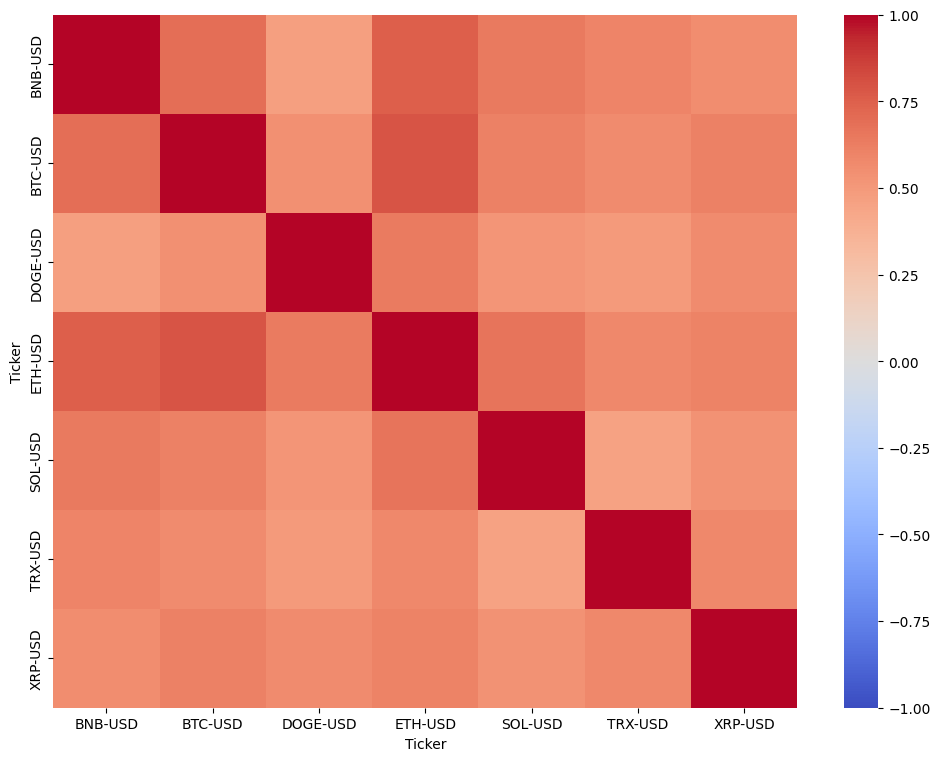

In [10]:
corr_matrix = log_returns.corr()

plt.figure(figsize=(12,9))
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

In [12]:
scaled_log_returns = StandardScaler().fit_transform(log_returns)

pca = PCA(n_components=3)
pca.fit(scaled_log_returns)

PCA(n_components=3)

In [13]:
pca.explained_variance_ratio_

array([0.65583788, 0.08607393, 0.079128  ])

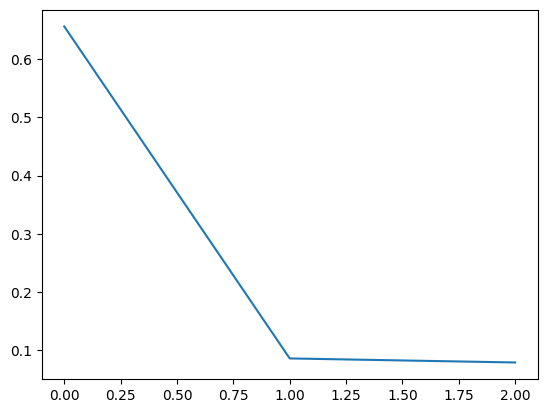

In [14]:
plt.figure()
plt.plot(pca.explained_variance_ratio_)
plt.show()

In [15]:
pca.components_[0]

array([0.39197979, 0.40100007, 0.34627828, 0.4182659 , 0.36665089,
       0.34956942, 0.36614768])

In [17]:
pc1_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[0] * 100
})

pc1_sorted = pc1_df.sort_values(by='Weight', ascending=False)

display(pc1_sorted)

,Ticker,Weight
3,ETH-USD,41.826590
1,BTC-USD,40.100007
0,BNB-USD,39.197979
4,SOL-USD,36.665089
6,XRP-USD,36.614768
5,TRX-USD,34.956942
2,DOGE-USD,34.627828


In [18]:
pc2_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[1] * 100
})

pc2_sorted = pc2_df.sort_values(by='Weight', ascending=False)
display(pc2_sorted)

,Ticker,Weight
5,TRX-USD,45.685529
2,DOGE-USD,44.731782
6,XRP-USD,43.182437
1,BTC-USD,-21.013647
3,ETH-USD,-21.377953
0,BNB-USD,-36.122825
4,SOL-USD,-42.938660


In [19]:
pc3_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[2] * 100
})

pc3_sorted = pc3_df.sort_values(by='Weight', ascending=False)

display(pc3_sorted)

,Ticker,Weight
2,DOGE-USD,67.595659
4,SOL-USD,26.350911
3,ETH-USD,8.898688
6,XRP-USD,-3.613692
1,BTC-USD,-5.698377
0,BNB-USD,-30.577373
5,TRX-USD,-60.636323
